# Plot pairOT mappings

In [1]:
%load_ext autoreload

In [2]:
from os.path import join

import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt

from anndata.experimental import read_elem
from IPython.display import display, Markdown

/vol/data/miniconda3/envs/sconnect/lib/python3.12/site-packages/anndata/experimental/__init__.py:48: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  return module_get_attr_redirect(


In [3]:
plt.rcParams["font.family"] = "sans-serif"

In [4]:
%autoreload
from pairot.plotting import plot_cluster_mapping, plot_cluster_distance
from pairot.dataset_ot import DatasetMapping

/vol/data/miniconda3/envs/sconnect/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/vol/data/miniconda3/envs/sconnect/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/vol/data/miniconda3/envs/sconnect/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [5]:
MODEL_DIR = "/vol/data/dataset-similarity/models/similarityOT"

In [6]:
def load_output(path, version):
    return (
        pd.read_parquet(join(path, version, "mapping_mean.parquet")),
        pd.read_parquet(join(path, version, "distance.parquet"))
    )


In [7]:
version_string_template = (
    "{query}+{ref}"
    "+n_genes_ova={n_genes_ova}"
    "+n_genes_ava=3"
    "+tau={tau}"
    "+epsilon=0.05"
    "+overlap_threshold_ava=0.3"
    "+overlap_n_genes_ava=10"
)

In [8]:
def convert_figma_to_inches(w, h):
    return (
        2. * (w / 684.) * 7.08661 * 1.1259,
        2. * (h / 684.) * 7.08661 * 1.1259
    )

## Figure 2

In [9]:
QUERY = "7d7cabfd-1d1f-40af-96b7-26a0825a306d"
REF = "ced320a1-29f3-47c1-a735-513c7084d508_CAP"

In [10]:
mapping_fig2, _ = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="1.0", n_genes_ova=10)
)

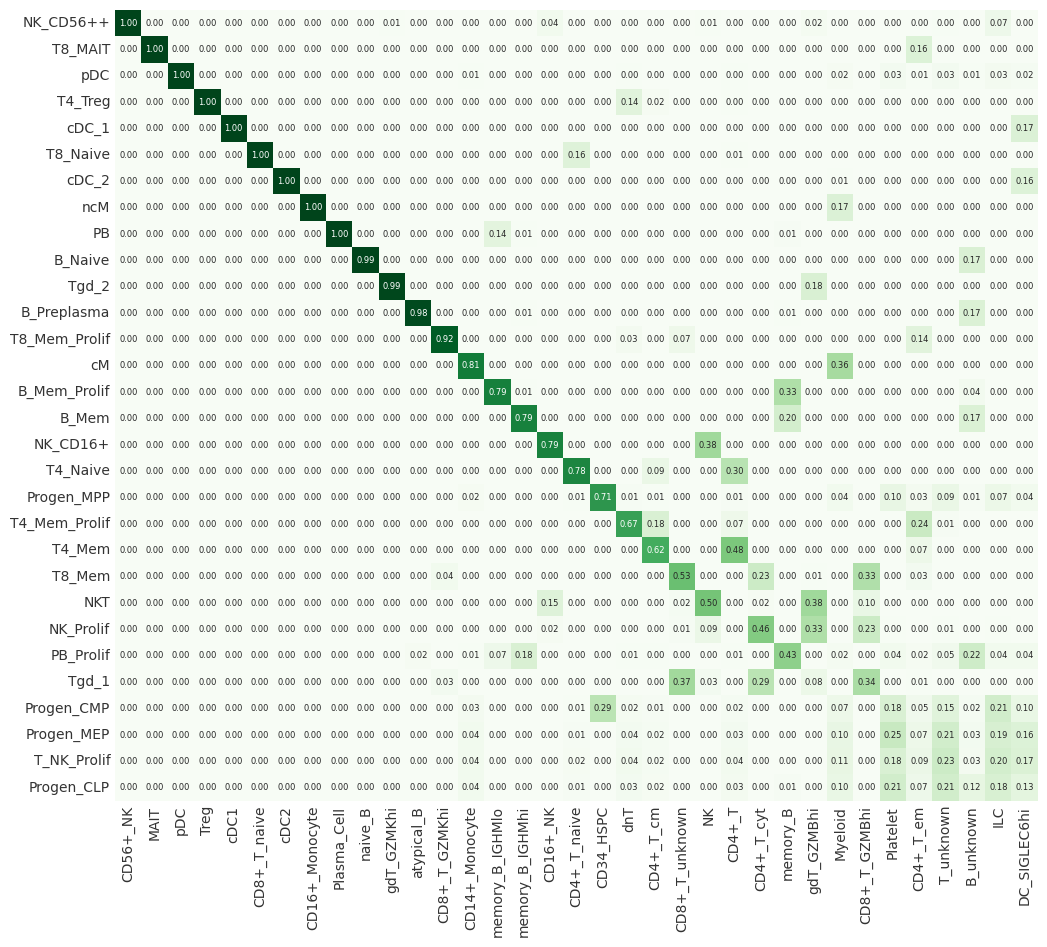

In [11]:
fig = plot_cluster_mapping(
    mapping_fig2, zmin=0., zmax=1., show=False, backend="matplotlib"
)
fig.set_size_inches(convert_figma_to_inches(510.35, 468.))
fig.savefig("mapping_plots/figure2_mapping.svg", bbox_inches="tight")

In [12]:
QUERY = "7d7cabfd-1d1f-40af-96b7-26a0825a306d_ct_coarse"
REF = "ced320a1-29f3-47c1-a735-513c7084d508_CAP_ct_coarse"

In [13]:
mapping_fig2_coarse, _ = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="1.0", n_genes_ova=10)
)

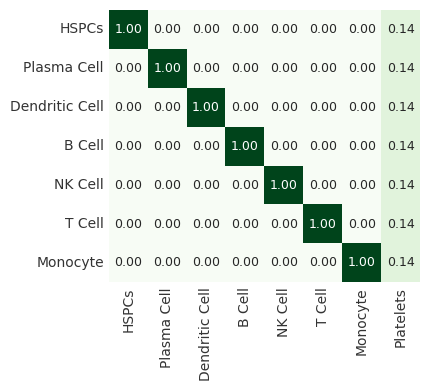

In [14]:
fig = plot_cluster_mapping(
    mapping_fig2_coarse, zmin=0., zmax=1., show=False, backend="matplotlib"
)
fig.set_size_inches(convert_figma_to_inches(172.2, 161.7))
for text in fig.axes[0].texts:
    text.set_fontsize(9)
fig.savefig("mapping_plots/figure2_mapping_coarse.svg", bbox_inches="tight")

## Figure 3

In [15]:
QUERY = "f6c50495-3361-40ed-a819-fb9644396ed9_updated"
REF = "ced320a1-29f3-47c1-a735-513c7084d508_CAP"

In [16]:
mapping_fig3, _ = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="0.95", n_genes_ova=10)
)

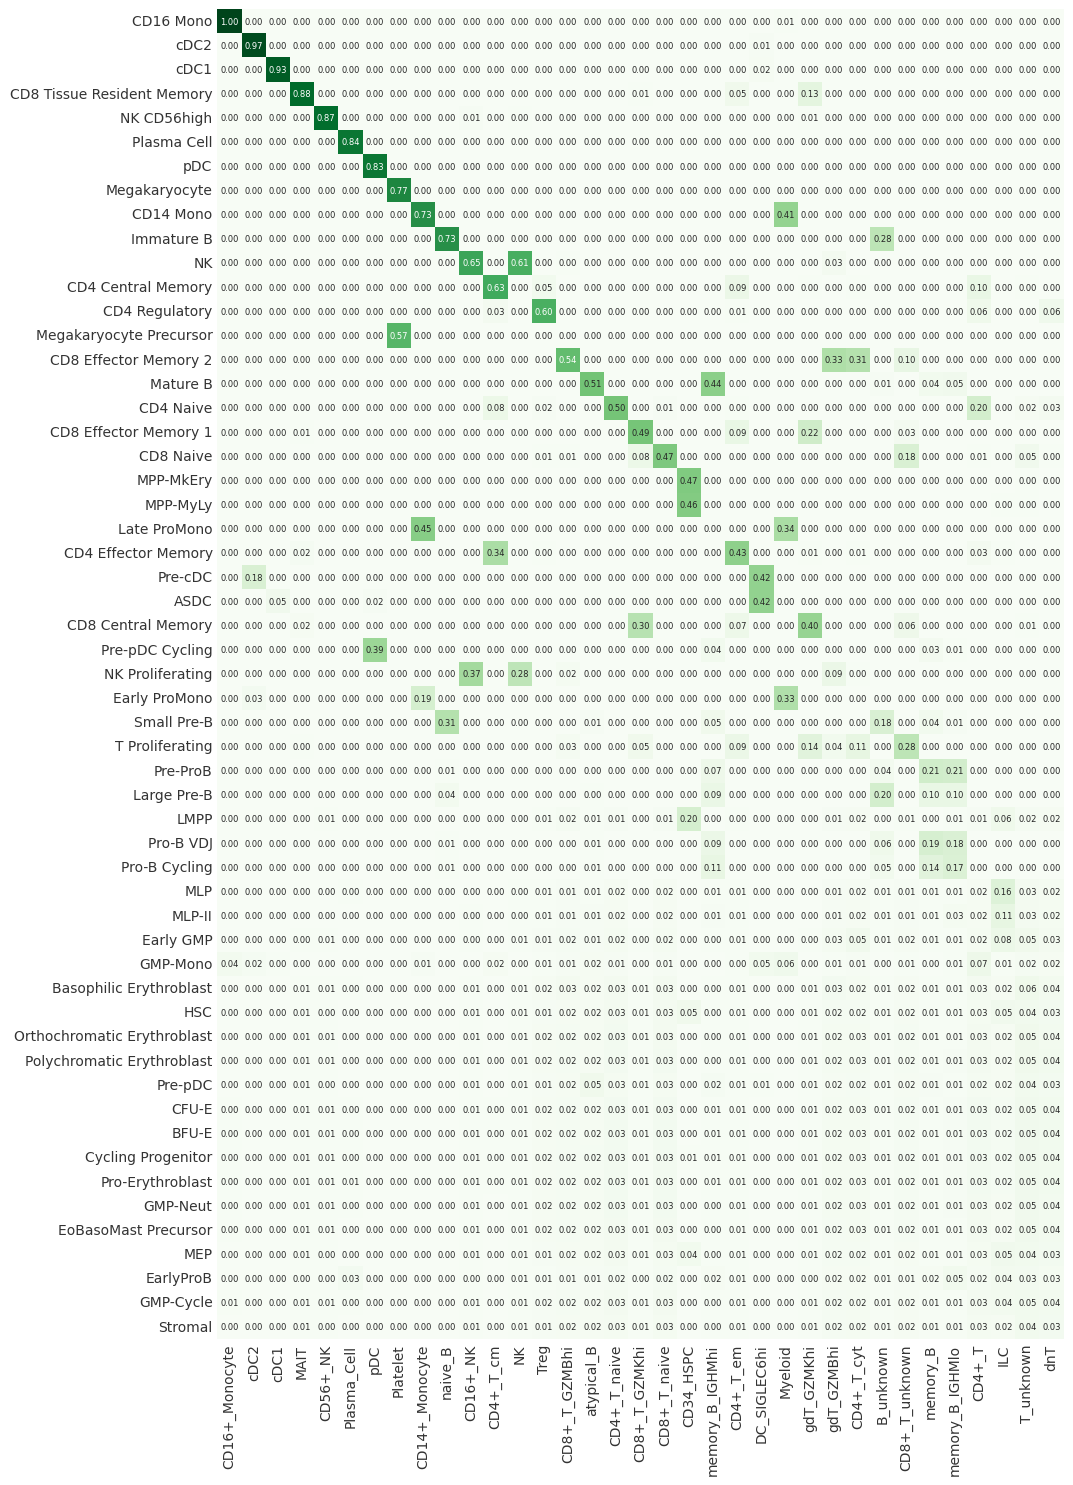

In [17]:
fig = plot_cluster_mapping(
    mapping_fig3, zmin=0., zmax=1., show=False, backend="matplotlib"
)
fig.set_size_inches(convert_figma_to_inches(510.35, 740.2))
fig.savefig("mapping_plots/figure3_mapping.svg", bbox_inches="tight")

## Figure 4

In [18]:
# use annot_kws={"size": 9} for sns.heatmap

In [19]:
QUERY = "Liver_macrophages"
REF = "Ileum_macrophages"

In [20]:
mapping_ileum, distance_ileum = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="0.975", n_genes_ova=15)
)

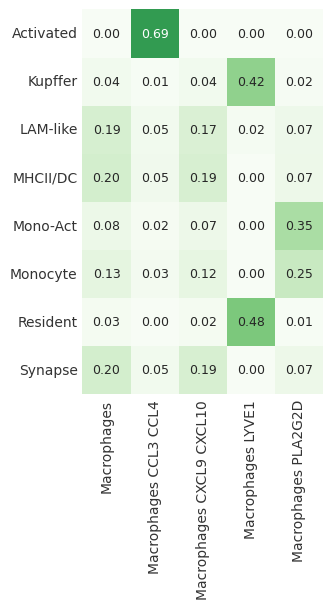

In [21]:
fig = plot_cluster_mapping(
    mapping_ileum, zmin=0., zmax=1., show=False, backend="matplotlib", sort_by_score=False
)
for text in fig.axes[0].texts:
    text.set_fontsize(9)
fig.savefig("mapping_plots/figure4_mapping_ileum.svg", bbox_inches="tight")

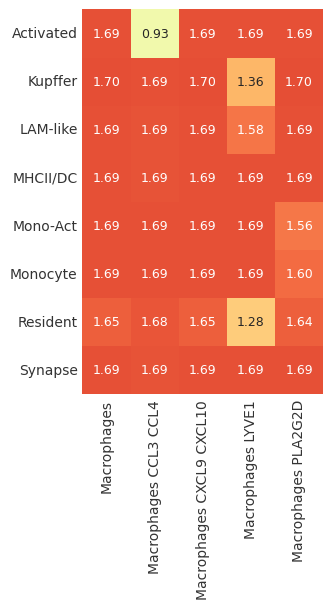

In [22]:
fig = plot_cluster_distance(
    distance_ileum, show=False, backend="matplotlib"
)
for text in fig.axes[0].texts:
    text.set_fontsize(9)
fig.savefig("mapping_plots/figure4_distance_ileum.svg", bbox_inches="tight")

In [23]:
QUERY = "Liver_macrophages"
REF = "Colon_macrophages"

In [24]:
mapping_colon, distance_colon = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="0.975", n_genes_ova=15)
)

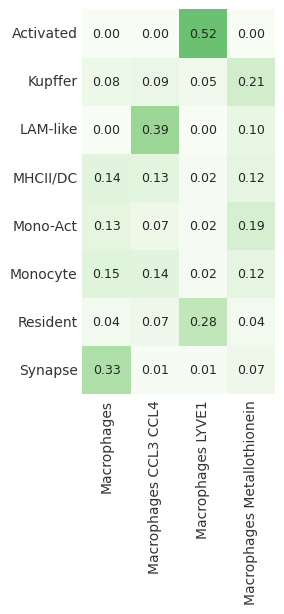

In [25]:
fig = plot_cluster_mapping(
    mapping_colon, zmin=0., zmax=1., show=False, backend="matplotlib", sort_by_score=False
)
for text in fig.axes[0].texts:
    text.set_fontsize(9)
fig.savefig("mapping_plots/figure4_mapping_colon.svg", bbox_inches="tight")

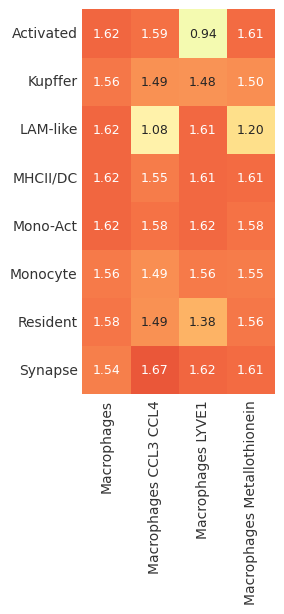

In [26]:
fig = plot_cluster_distance(
    distance_colon, show=False, backend="matplotlib"
)
for text in fig.axes[0].texts:
    text.set_fontsize(9)
fig.savefig("mapping_plots/figure4_distance_colon.svg", bbox_inches="tight")

In [27]:
QUERY = "Liver_macrophages"
REF = "Colon_macrophages_felix"

In [28]:
mapping_colon_felix, distance_colon_felix = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="0.975", n_genes_ova=15)
)

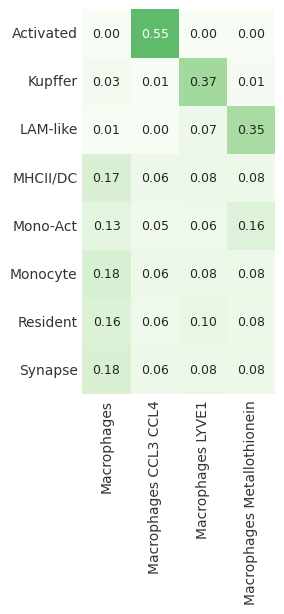

In [29]:
fig = plot_cluster_mapping(
    mapping_colon_felix, zmin=0., zmax=1., show=False, backend="matplotlib", sort_by_score=False
)
for text in fig.axes[0].texts:
    text.set_fontsize(9)
fig.savefig("mapping_plots/figure4_mapping_colon_felix.svg", bbox_inches="tight")

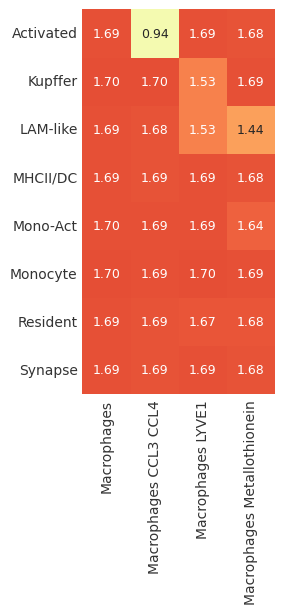

In [30]:
fig = plot_cluster_distance(
    distance_colon_felix, show=False, backend="matplotlib"
)
for text in fig.axes[0].texts:
    text.set_fontsize(9)
fig.savefig("mapping_plots/figure4_distance_felix.svg", bbox_inches="tight")

## Figure 5

In [31]:
QUERY = "71f4bccf-53d4-4c12-9e80-e73bfb89e398"
REF = "0f528c8a-a25c-4840-8fa3-d156fa11086f"

In [32]:
mapping_gingiva, distance_gingiva = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="1.0", n_genes_ova=10)
)

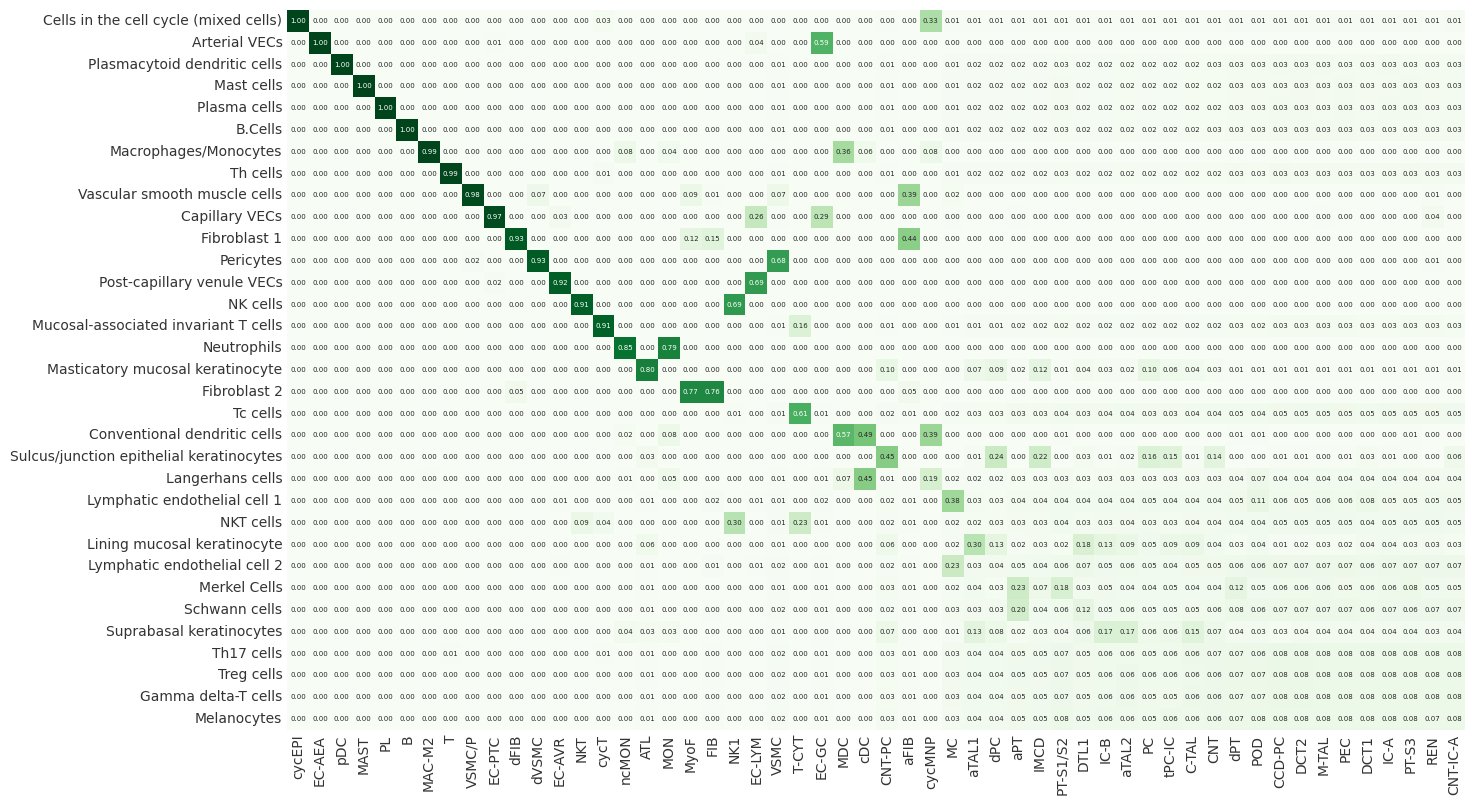

In [33]:
fig = plot_cluster_mapping(
    mapping_gingiva, zmin=0., zmax=1., show=False, backend="matplotlib"
)
for text in fig.axes[0].texts:
    text.set_fontsize(5)

fig.savefig("mapping_plots/figure5_mapping.svg", bbox_inches="tight")

In [34]:
QUERY = "71f4bccf-53d4-4c12-9e80-e73bfb89e398"
REF = "0f528c8a-a25c-4840-8fa3-d156fa11086f_Treg"

In [35]:
mapping_gingiva_Treg, distance_gingiva_Treg = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="1.0", n_genes_ova=10)
)

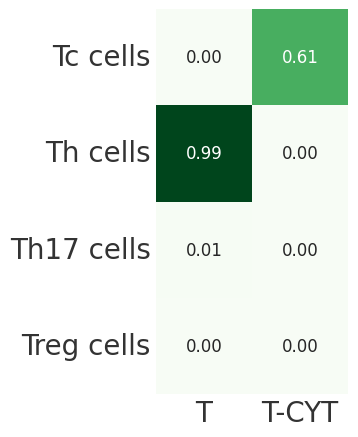

In [36]:
fig = plot_cluster_mapping(
    mapping_gingiva.loc[["Tc cells", "Th cells", "Th17 cells", "Treg cells"], ["T", "T-CYT"]],
    zmin=0., zmax=1., sort_by_score=False, show=False, backend="matplotlib"
)
fig.axes[0].tick_params(axis='x', labelsize=20)
fig.axes[0].tick_params(axis='y', labelsize=20, rotation=0)
for text in fig.axes[0].texts:
    text.set_fontsize(12)
fig.savefig("mapping_plots/figure5_Treg_before.svg", bbox_inches="tight")

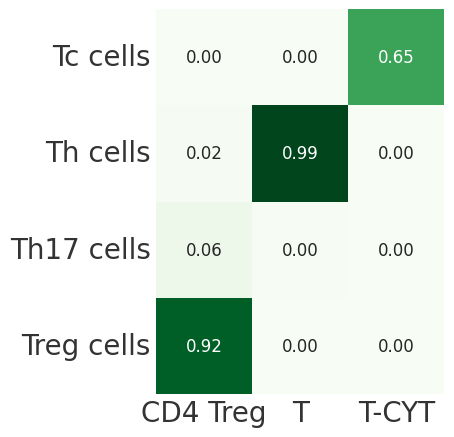

In [37]:
# after
fig = plot_cluster_mapping(
    mapping_gingiva_Treg.loc[["Tc cells", "Th cells", "Th17 cells", "Treg cells"], ["CD4 Treg", "T", "T-CYT"]],
    zmin=0., zmax=1., sort_by_score=False, show=False, backend="matplotlib"
)
fig.axes[0].tick_params(axis='x', labelsize=20)
fig.axes[0].tick_params(axis='y', labelsize=20, rotation=0)
for text in fig.axes[0].texts:
    text.set_fontsize(12)
fig.savefig("mapping_plots/figure5_Treg_after.svg", bbox_inches="tight")

In [38]:
QUERY = "71f4bccf-53d4-4c12-9e80-e73bfb89e398"
REF = "0f528c8a-a25c-4840-8fa3-d156fa11086f_aFIB"

In [39]:
mapping_gingiva_VSMC_aFIB, distance_gingiva_VSMC_aFIB = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="1.0", n_genes_ova=10)
)

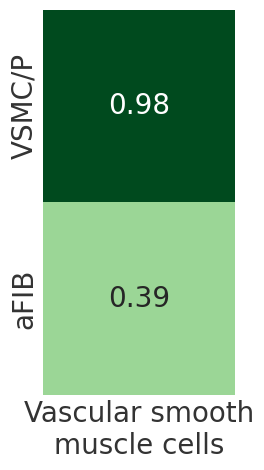

In [40]:
fig = plot_cluster_mapping(
    mapping_gingiva.loc[["Vascular smooth muscle cells"], ["VSMC/P", "aFIB"]].T,
    zmin=0., zmax=1., sort_by_score=False, show=False, backend="matplotlib"
)
fig.axes[0].set_xticklabels(["Vascular smooth\nmuscle cells"])
fig.axes[0].tick_params(axis='x', labelsize=20)
fig.axes[0].tick_params(axis='y', labelsize=20)
for text in fig.axes[0].texts:
    text.set_fontsize(20)
fig.savefig("mapping_plots/figure5_aFIB_before.svg", bbox_inches="tight")

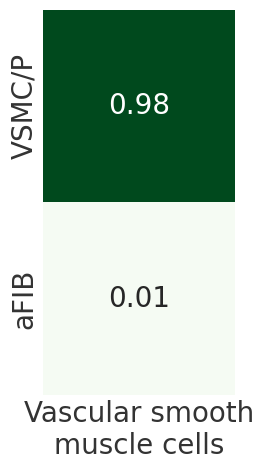

In [41]:
fig = plot_cluster_mapping(
    mapping_gingiva_VSMC_aFIB.loc[["Vascular smooth muscle cells"], ["VSMC/P", "aFIB"]].T,
    zmin=0., zmax=1., sort_by_score=False, show=False, backend="matplotlib"
)
fig.axes[0].set_xticklabels(["Vascular smooth\nmuscle cells"])
fig.axes[0].tick_params(axis='x', labelsize=20)
fig.axes[0].tick_params(axis='y', labelsize=20)
for text in fig.axes[0].texts:
    text.set_fontsize(20)
fig.savefig("mapping_plots/figure5_aFIB_after.svg", bbox_inches="tight")

## Supp. Figure 3

In [42]:
QUERY = "7d7cabfd-1d1f-40af-96b7-26a0825a306d"
REF = "ced320a1-29f3-47c1-a735-513c7084d508_CAP_CD4_naive"

In [43]:
mapping_immune_CD4_naive, distance_immune_CD4_naive = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="1.0", n_genes_ova=10)
)

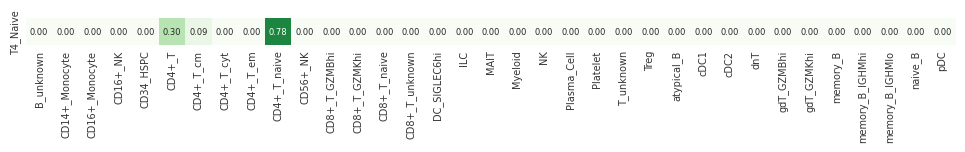

In [44]:
fig = plot_cluster_mapping(
    mapping_fig2.loc[["T4_Naive"], :], 
    zmin=0., zmax=1., sort_by_score=False, show=False,
    width=1200, height=300, backend="matplotlib"
)
fig.axes[0].tick_params(axis='x', labelsize=7)
fig.axes[0].tick_params(axis='y', labelsize=7)
fig.savefig("mapping_plots/supp_fig3_AIDA_before.svg", bbox_inches="tight")

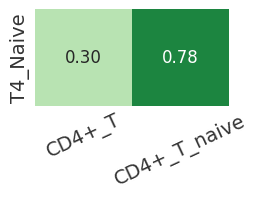

In [45]:
fig = plot_cluster_mapping(
    mapping_fig2.loc[["T4_Naive"], ["CD4+_T", "CD4+_T_naive"]], 
    zmin=0., zmax=1., sort_by_score=False, show=False, backend="matplotlib",
    width=250, height=250,
)
fig.axes[0].tick_params(axis='x', labelsize=14, rotation=25)
fig.axes[0].tick_params(axis='y', labelsize=14)
for text in fig.axes[0].texts:
    text.set_fontsize(12)
fig.savefig("mapping_plots/supp_fig3_AIDA_before_zoomed.svg", bbox_inches="tight")

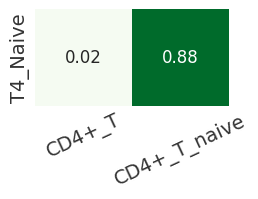

In [46]:
fig = plot_cluster_mapping(
    mapping_immune_CD4_naive.loc[["T4_Naive"], ["CD4+_T", "CD4+_T_naive"]], 
    zmin=0., zmax=1., sort_by_score=False, show=False, backend="matplotlib",
    width=250, height=250,
)
fig.axes[0].tick_params(axis='x', labelsize=14, rotation=25)
fig.axes[0].tick_params(axis='y', labelsize=14)
for text in fig.axes[0].texts:
    text.set_fontsize(12)
fig.savefig("mapping_plots/supp_fig3_AIDA_after_zoomed.svg", bbox_inches="tight")

In [47]:
QUERY = "f6c50495-3361-40ed-a819-fb9644396ed9_updated"
REF = "ced320a1-29f3-47c1-a735-513c7084d508_CAP_CD4_naive"

In [48]:
mapping_bonemarrow_CD4_naive, distance_bonemarrow_CD4_naive = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="0.95", n_genes_ova=10)
)

#### Alphabetical sorting

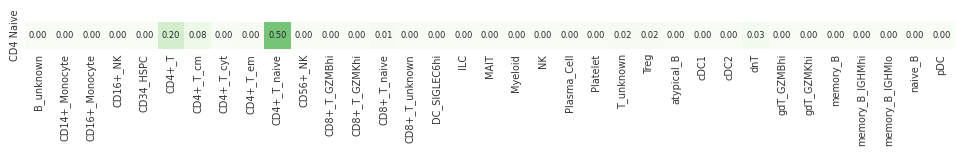

In [49]:
fig = plot_cluster_mapping(
    mapping_fig3.loc[["CD4 Naive"], :], 
    zmin=0., zmax=1., sort_by_score=False, show=False,
    width=1200, height=300, backend="matplotlib"
)
fig.axes[0].tick_params(axis='x', labelsize=7)
fig.axes[0].tick_params(axis='y', labelsize=7)
fig.savefig("mapping_plots/supp_fig3_bonemarrow_before.svg", bbox_inches="tight")

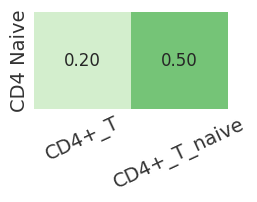

In [50]:
fig = plot_cluster_mapping(
    mapping_fig3.loc[["CD4 Naive"], ["CD4+_T", "CD4+_T_naive"]], 
    zmin=0., zmax=1., sort_by_score=False, show=False,
    width=250, height=250, backend="matplotlib"
)
fig.axes[0].tick_params(axis='x', labelsize=14, rotation=25)
fig.axes[0].tick_params(axis='y', labelsize=14)
for text in fig.axes[0].texts:
    text.set_fontsize(12)
fig.savefig("mapping_plots/supp_fig3_bonemarrow_before_zoomed.svg", bbox_inches="tight")

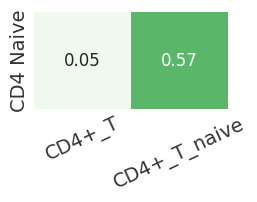

In [51]:
fig = plot_cluster_mapping(
    mapping_bonemarrow_CD4_naive.loc[["CD4 Naive"], ["CD4+_T", "CD4+_T_naive"]], 
    zmin=0., zmax=1., sort_by_score=False, show=False,
    width=250, height=250, backend="matplotlib"
)
fig.axes[0].tick_params(axis='x', labelsize=14, rotation=25)
fig.axes[0].tick_params(axis='y', labelsize=14)
for text in fig.axes[0].texts:
    text.set_fontsize(12)
fig.savefig("mapping_plots/supp_fig3_bonemarrow_after_zoomed.svg", bbox_inches="tight")

## Supp. Figure 5

In [52]:
QUERY = "7d7cabfd-1d1f-40af-96b7-26a0825a306d"
REF = "ced320a1-29f3-47c1-a735-513c7084d508_CAP_NKT_CD3E"

In [53]:
mapping_immune_NKT, distance_immune_NKT = load_output(
    MODEL_DIR,
    version_string_template.format(query=QUERY, ref=REF, tau="1.0", n_genes_ova=10)
)

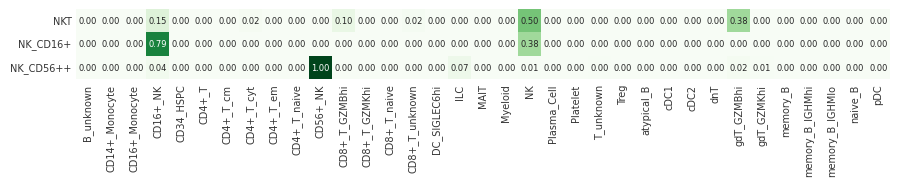

In [54]:
fig = plot_cluster_mapping(
    mapping_fig2.loc[["NKT", "NK_CD16+", "NK_CD56++"], :], 
    zmin=0., zmax=1., sort_by_score=False, show=False, backend="matplotlib"
)
fig.axes[0].tick_params(axis='x', labelsize=7)
fig.axes[0].tick_params(axis='y', labelsize=7)
fig.savefig("mapping_plots/supp_fig5_NKT_before.svg", bbox_inches="tight")

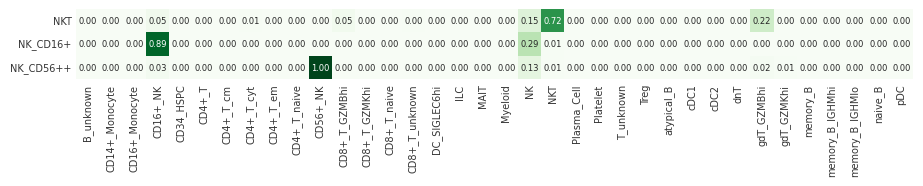

In [55]:
fig = plot_cluster_mapping(
    mapping_immune_NKT.loc[["NKT", "NK_CD16+", "NK_CD56++"], :], 
    zmin=0., zmax=1., sort_by_score=False, show=False, backend="matplotlib"
)
fig.axes[0].tick_params(axis='x', labelsize=7)
fig.axes[0].tick_params(axis='y', labelsize=7)
fig.savefig("mapping_plots/supp_fig5_NKT_after.svg", bbox_inches="tight")